## Pirâmide gaussiana de imagens

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import convolve


def downsample(img):
    """Gera uma nova imagem com metade do tamanho da imagem de entrada. A imagem de
       entrada é suavizada utilizando um filtro gaussiano e amostrada a cada 2 pixels"""
    
    # Criação do filtro gaussiano
    #[[1,  4,  6,  4, 1],
    # [4, 16, 24, 16, 4],
    # [6, 24, 36, 24, 6],
    # [4, 16, 24, 16, 4],
    # [1,  4,  6,  4, 1]])
    # Matriz de tamanho 1x5
    k = np.array([[1, 4, 6, 4, 1]])
    # O filtro gaussiano é criado a partir do produto matricial entre a matriz k transposta
    # # de tamanho 5x1 e a matriz k, resultando em uma matriz de tamanho 5x5
    gauss_filt = k.T @ k
    gauss_filt = gauss_filt/256.
    
    img = img.astype(float)
    num_rows, num_cols = img.shape
    half_num_rows = (num_rows+1)//2
    half_num_cols = (num_cols+1)//2
    
    img_smooth = convolve(img, gauss_filt, mode="same")
    img_down = np.zeros([half_num_rows,half_num_cols])
    for row in range(half_num_rows):
        for col in range(half_num_cols):
            img_down[row, col] = img_smooth[2*row, 2*col]
            
    return img_down

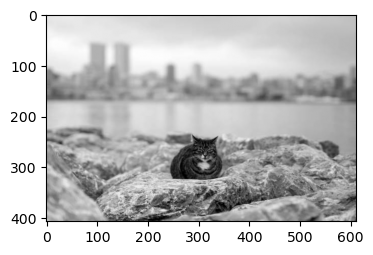

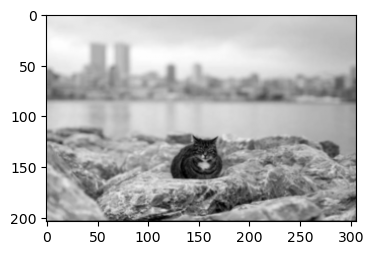

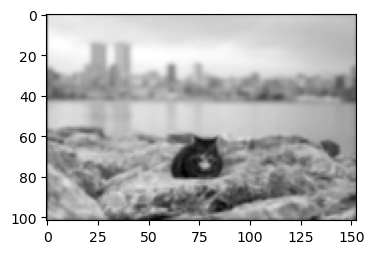

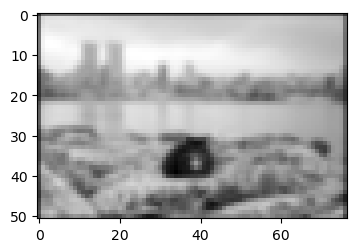

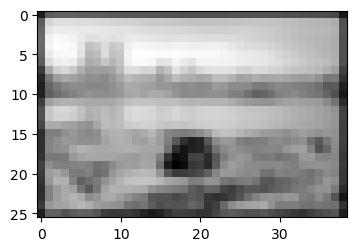

In [8]:
img = plt.imread("../../dados/imagem_global.tiff")

img_2x = downsample(img)
img_4x = downsample(img_2x)
img_8x = downsample(img_4x)
img_16x = downsample(img_8x)

plt.figure()
plt.imshow(img, "gray")
plt.figure()
plt.imshow(img_2x, "gray")
plt.figure()
plt.imshow(img_4x, "gray")
plt.figure()
plt.imshow(img_8x, "gray")
plt.figure()
plt.imshow(img_16x, "gray")

Note que a biblioteca matplotlib mostra as imagens com o tamanho requisitado. Para isso, a imagem é interpolada no momento da visualização.

Note também que a imagem fica mais escura próximo às bordas. Poderíamos evitar efeitos de borda utilizando métodos de preenchimento de borda mais robustos. Por exemplo, refletir os valores próximos à borda.

#### Mostra imagens utilizando um tamanho compatível com a resolução delas

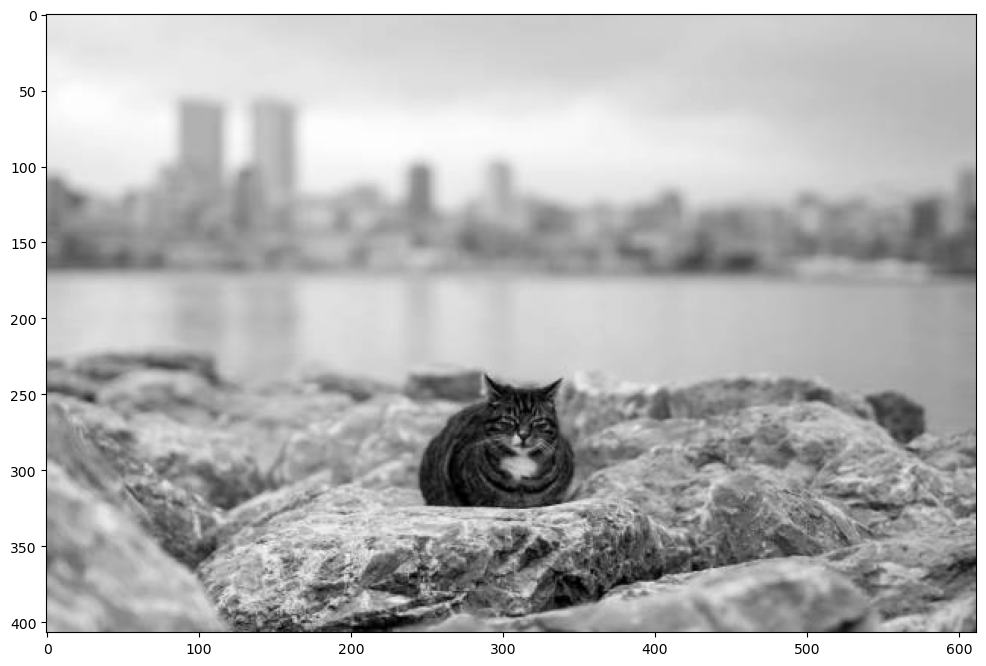

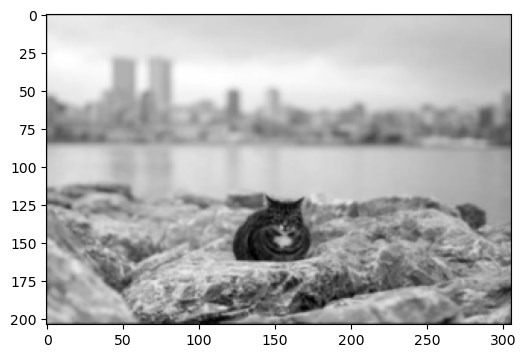

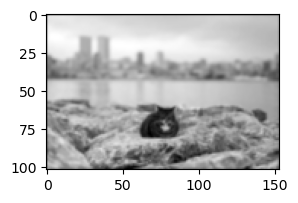

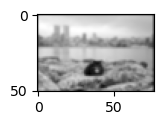

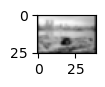

In [9]:
fig_size = 12

plt.figure(figsize=[fig_size, fig_size])
plt.imshow(img, "gray")
plt.figure(figsize=[fig_size/2, fig_size/2])
plt.imshow(img_2x, "gray")
plt.figure(figsize=[fig_size/4, fig_size/4])
plt.imshow(img_4x, "gray")
plt.figure(figsize=[fig_size/8, fig_size/8])
plt.imshow(img_8x, "gray")
plt.figure(figsize=[fig_size/16, fig_size/16])
plt.imshow(img_16x, "gray")

#### Detalhe, podemos armazenar todos os níveis da pirâmide numa lista

In [10]:
num_levels = 5

pyramid = [img]
img_down = downsample(img)
pyramid.append(img_down)
for i in range(num_levels-2):
    img_down = downsample(img_down)
    pyramid.append(img_down)

#### Pirâmides utilizando a biblioteca opencv

In [ ]:
import cv2

img_2x_cv = cv2.pyrDown(img)
img_4x_cv = cv2.pyrDown(img_2x_cv)